In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt


Retorno acumulado total (com CDI): 77.07%
CDI acumulado jul/2022–dez/2025 : 52.77%
CDI anualizado equivalente      : 12.89%
Ibovespa acumulado jul/2022–dez/2025 : 62.75%
Ibovespa anualizado equivalente      : 15.00%

Dias com posição em pares: 425
Dias totais              : 866

═══ Estatísticas da Estratégia Pairs Trading (2022–2025) ═══════
Período              : 2022-07-04 → 2025-12-30
Anos                 : 3.49
Dias ativos (pares)  : 425 de 866 dias totais

Métrica                          Estratégia          CDI     Ibovespa
──────────────────────────────────────────────────────────────────
Retorno acumulado                    77.07%       52.77%       62.75%
Retorno anualizado                   17.78%       12.89%       15.00%
Volatilidade anual                   15.36%            —            —
Sharpe anualizado                    0.5689            —            —
Maximum Drawdown                    -10.79%            —            —
Beta vs Ibovespa                     0.1677   

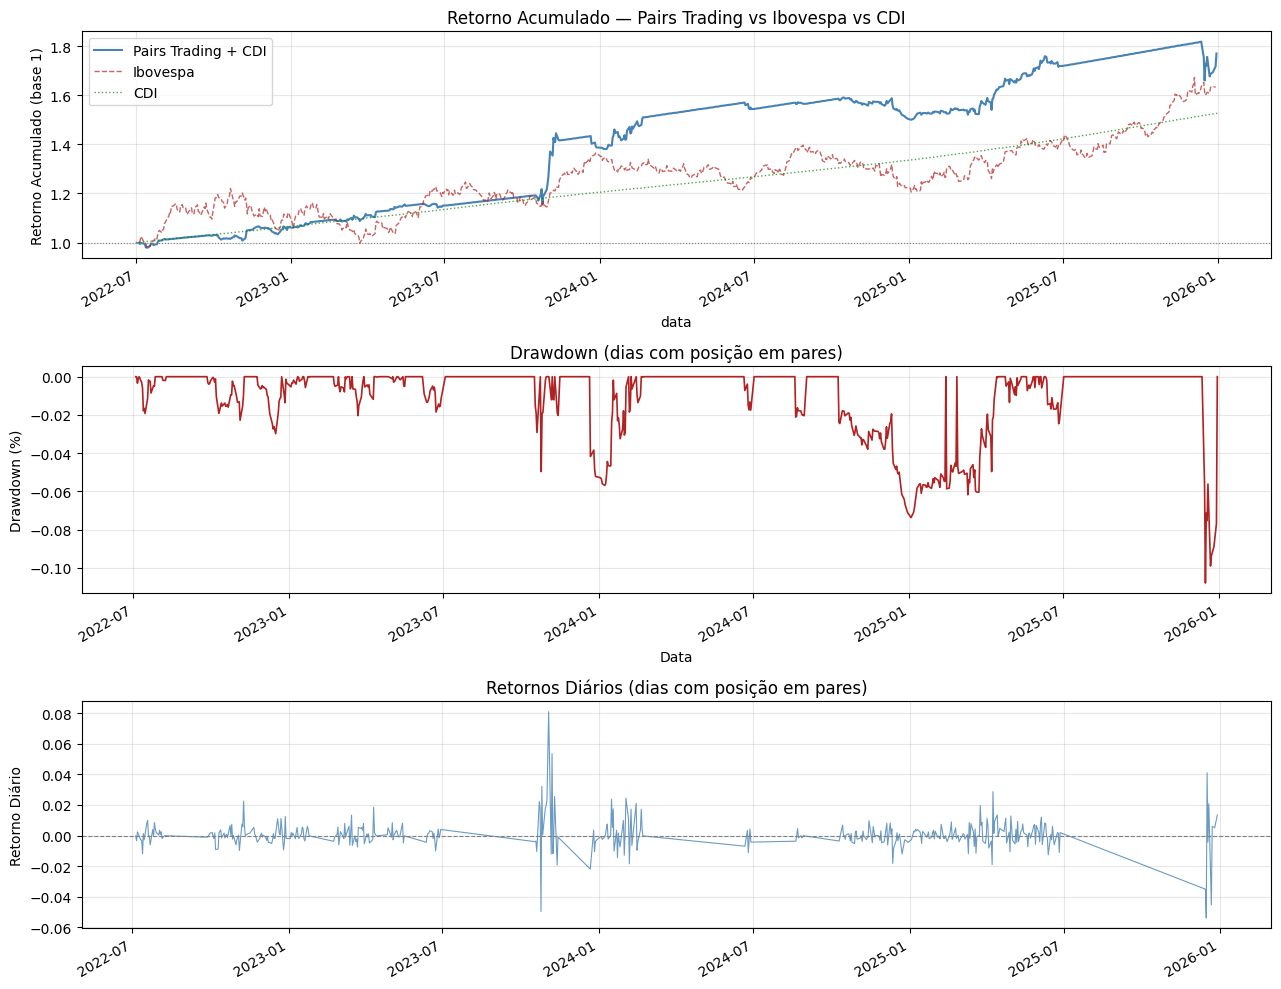


Gráfico salvo em 'analise_estrategia.png'


In [15]:
# ── 1. Carrega a planilha ─────────────────────────────────────────────────────
df_total = pd.read_excel('Resultados_com_CDI.xlsx')
df_total.columns = ['Data', 'Retorno_Diario', 'Retorno_Acumulado_Planilha']
df_total['Data'] = pd.to_datetime(df_total['Data'])
df_total = df_total.set_index('Data').dropna(subset=['Retorno_Diario'])
df_total['Retorno_Acumulado'] = (1 + df_total['Retorno_Diario']).cumprod()

df_pares = pd.read_excel('Resultados.xlsx')
df_pares.columns = ['Data', 'Retorno_Pares', 'Retorno_Acumulado_Planilha']
df_pares['Data'] = pd.to_datetime(df_pares['Data'])
df_pares = df_pares.set_index('Data').dropna(subset=['Retorno_Pares'])

print(f"Retorno acumulado total (com CDI): {(df_total['Retorno_Acumulado'].iloc[-1] - 1) * 100:.2f}%")

# ── 2. CDI do Banco Central ───────────────────────────────────────────────────
import requests

url = "https://api.bcb.gov.br/dados/serie/bcdata.sgs.12/dados?formato=json&dataInicial=01/07/2022&dataFinal=31/12/2025"
response  = requests.get(url)
cdi_data  = response.json()
cdi_df    = pd.DataFrame(cdi_data)
cdi_df['data']  = pd.to_datetime(cdi_df['data'], format='%d/%m/%Y')
cdi_df['valor'] = pd.to_numeric(cdi_df['valor']) / 100
cdi_df    = cdi_df.set_index('data').sort_index()

cdi_acumulado = (1 + cdi_df['valor']).prod() - 1
cdi_diario    = cdi_df['valor'].mean()
cdi_anual     = (1 + cdi_diario) ** 252 - 1

print(f"CDI acumulado jul/2022–dez/2025 : {cdi_acumulado * 100:.2f}%")
print(f"CDI anualizado equivalente      : {cdi_anual * 100:.2f}%")

# ── 3. Baixa o Ibovespa ───────────────────────────────────────────────────────
inicio = df_total.index[0].strftime('%Y-%m-%d')
fim    = df_total.index[-1].strftime('%Y-%m-%d')

ibov_raw = yf.download('^BVSP', start=inicio, end=fim,
                        auto_adjust=True, progress=False)['Close']
if isinstance(ibov_raw, pd.DataFrame):
    ibov_raw = ibov_raw.squeeze()

ibov_ret = ibov_raw.pct_change().dropna()
ibov_ret.index = pd.to_datetime(ibov_ret.index.strftime('%Y-%m-%d'))
ibov_ret.name = 'IBOV'

# Ibovespa acumulado e anualizado
ibov_acum_total = (1 + ibov_ret).prod() - 1
anos_ibov       = (ibov_ret.index[-1] - ibov_ret.index[0]).days / 365.25
ibov_anual      = (1 + ibov_acum_total) ** (1 / anos_ibov) - 1

print(f"Ibovespa acumulado jul/2022–dez/2025 : {ibov_acum_total * 100:.2f}%")
print(f"Ibovespa anualizado equivalente      : {ibov_anual * 100:.2f}%")

# ── 4. Dias ativos = dias com retorno de PARES diferente de zero ──────────────
df_merged = df_pares[['Retorno_Pares']].join(ibov_ret, how='inner')
df_ativos = df_merged[df_merged['Retorno_Pares'] != 0].copy()

print(f"\nDias com posição em pares: {len(df_ativos)}")
print(f"Dias totais              : {len(df_total)}")

# ── 5. Métricas da estratégia ─────────────────────────────────────────────────
ret_diario = df_ativos['Retorno_Pares']
ret_acum   = (1 + ret_diario).cumprod()
pico       = ret_acum.cummax()
drawdown   = (ret_acum - pico) / pico
mdd        = drawdown.min()

# Retorno anualizado — período completo com CDI
anos          = (df_total.index[-1] - df_total.index[0]).days / 365.25
retorno_total = df_total['Retorno_Acumulado'].iloc[-1] - 1
ret_anual     = (1 + retorno_total) ** (1 / anos) - 1

# Volatilidade — apenas dias com posição em pares
vol_anual = ret_diario.std() * np.sqrt(252)

# Sharpe com CDI como taxa livre de risco — dias ativos
excesso_diario = ret_diario - cdi_diario
sharpe         = (excesso_diario.mean() * 252) / vol_anual

# ── 6. Beta e correlação com o Ibovespa ───────────────────────────────────────
ibov_ativos = df_ativos['IBOV']
cov_matrix  = np.cov(ret_diario, ibov_ativos)
beta        = cov_matrix[0, 1] / cov_matrix[1, 1]
correlacao  = np.corrcoef(ret_diario, ibov_ativos)[0, 1]

# ── 7. Resumo estatístico ─────────────────────────────────────────────────────
print("\n═══ Estatísticas da Estratégia Pairs Trading (2022–2025) ═══════")
print(f"Período              : {df_total.index[0].date()} → {df_total.index[-1].date()}")
print(f"Anos                 : {anos:.2f}")
print(f"Dias ativos (pares)  : {len(df_ativos)} de {len(df_total)} dias totais")
print(f"")
print(f"{'Métrica':<30} {'Estratégia':>12} {'CDI':>12} {'Ibovespa':>12}")
print(f"{'─' * 66}")
print(f"{'Retorno acumulado':<30} {retorno_total * 100:>11.2f}% {cdi_acumulado * 100:>11.2f}% {ibov_acum_total * 100:>11.2f}%")
print(f"{'Retorno anualizado':<30} {ret_anual * 100:>11.2f}% {cdi_anual * 100:>11.2f}% {ibov_anual * 100:>11.2f}%")
print(f"{'Volatilidade anual':<30} {vol_anual * 100:>11.2f}% {'—':>12} {'—':>12}")
print(f"{'Sharpe anualizado':<30} {sharpe:>12.4f} {'—':>12} {'—':>12}")
print(f"{'Maximum Drawdown':<30} {mdd * 100:>11.2f}% {'—':>12} {'—':>12}")
print(f"{'Beta vs Ibovespa':<30} {beta:>12.4f} {'—':>12} {'—':>12}")
print(f"{'Correlação Ibovespa':<30} {correlacao:>12.4f} {'—':>12} {'—':>12}")

# ── 8. Gráfico ────────────────────────────────────────────────────────────────
ibov_acum = (1 + ibov_raw.pct_change().dropna()).cumprod()
ibov_acum = ibov_acum / ibov_acum.iloc[0]

cdi_acum = (1 + cdi_df['valor']).cumprod()
cdi_acum = cdi_acum / cdi_acum.iloc[0]

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=False)

# Painel 1 — Retorno acumulado
df_total['Retorno_Acumulado'].plot(ax=axes[0], color='steelblue',
                                    linewidth=1.5, label='Pairs Trading + CDI')
ibov_acum.plot(ax=axes[0], color='firebrick', linewidth=1,
               linestyle='--', label='Ibovespa', alpha=0.7)
cdi_acum.plot(ax=axes[0], color='green', linewidth=1,
              linestyle=':', label='CDI', alpha=0.7)
axes[0].set_title('Retorno Acumulado — Pairs Trading vs Ibovespa vs CDI')
axes[0].set_ylabel('Retorno Acumulado (base 1)')
axes[0].axhline(1, color='gray', linestyle=':', linewidth=0.8)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Painel 2 — Drawdown (apenas dias com posição em pares)
drawdown_completo = pd.Series(0.0, index=df_total.index)
drawdown_completo.loc[df_ativos.index] = drawdown.values
drawdown_completo.plot(ax=axes[1], color='firebrick', linewidth=1.2)
axes[1].set_title('Drawdown (dias com posição em pares)')
axes[1].set_ylabel('Drawdown (%)')
axes[1].grid(True, alpha=0.3)

# Painel 3 — Retornos diários (apenas dias com posição em pares)
ret_diario.plot(ax=axes[2], color='steelblue', linewidth=0.8, alpha=0.8)
axes[2].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[2].set_title('Retornos Diários (dias com posição em pares)')
axes[2].set_ylabel('Retorno Diário')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('analise_estrategia.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nGráfico salvo em 'analise_estrategia.png'")